In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
DATA_PATH = "../data/mdm2_data_files/master_mobility_model_data.csv"

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

print("Rows:", len(df))
print("Sensors:", df["sensor_id"].nunique())
df.head()


Rows: 379477
Sensors: 46


,sensor_id,datetime,date_only,hour,dow,is_weekend,week,month,year,longitude,...,solar_altitude_deg,light_class,Dark,temp_c,wind_ms,rain_mm,cctv_300m,safety_after_dark_pct,safety_scaled,weekday
0,1,2024-01-01 00:00:00+00:00,2024-01-01,0,0,0,1,1,2024,-2.591538,...,-61.529806,darkness,1,7.8,15.0,0.0,52,53.5,0.460744,0
1,1,2024-01-01 01:00:00+00:00,2024-01-01,1,0,0,1,1,2024,-2.591538,...,-60.225898,darkness,1,8.0,14.0,0.0,52,53.5,0.460744,0
2,1,2024-01-01 02:00:00+00:00,2024-01-01,2,0,0,1,1,2024,-2.591538,...,-54.953852,darkness,1,8.0,16.0,0.0,52,53.5,0.460744,0
3,1,2024-01-01 03:00:00+00:00,2024-01-01,3,0,0,1,1,2024,-2.591538,...,-47.266506,darkness,1,7.6,14.0,0.0,52,53.5,0.460744,0
4,1,2024-01-01 04:00:00+00:00,2024-01-01,4,0,0,1,1,2024,-2.591538,...,-38.404055,darkness,1,7.4,12.0,0.0,52,53.5,0.460744,0


In [3]:
df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce").dt.date

In [4]:
light_summary = df.groupby("hour")["Dark"].agg(["min","max","mean"]).reset_index()
light_summary

,hour,min,max,mean
0,0,1,1,1.000000
1,1,1,1,1.000000
2,2,1,1,1.000000
3,3,1,1,1.000000
4,4,0,1,0.964220
5,5,0,1,0.654793
6,6,0,1,0.455457
7,7,0,1,0.255452
8,8,0,0,0.000000
9,9,0,0,0.000000


In [5]:
case_hours = light_summary.loc[
    (light_summary["min"]==0) & (light_summary["max"]==1),
    "hour"
].tolist()

print("Case hours:", case_hours)

Case hours: [4, 5, 6, 7, 17, 18, 19, 20]


In [6]:
valid_case_hours = []

for h in case_hours:
    sub = df[df["hour"] == h]

    dark_months = sub.loc[sub["Dark"] == 1, "month"].nunique()
    light_months = sub.loc[sub["Dark"] == 0, "month"].nunique()

    # Require at least 3 months in each condition
    if dark_months >= 3 and light_months >= 3:
        valid_case_hours.append(h)

print("Original case hours:", case_hours)
print("Filtered valid case hours:", valid_case_hours)

case_hours = valid_case_hours

Original case hours: [4, 5, 6, 7, 17, 18, 19, 20]
Filtered valid case hours: [5, 6, 7, 17, 18, 19, 20]


In [7]:
day_control_hour = 13
dark_control_hour = 23

print("Day control hour:", day_control_hour)
print("Dark control hour:", dark_control_hour)

Day control hour: 13
Dark control hour: 23


In [8]:
def compute_sensor_level_or(data, outcome, case_hour, day_control_hour, dark_control_hour):
    rows = []

    for sensor in sorted(data["sensor_id"].unique()):
        sub = data[data["sensor_id"] == sensor].copy()

        # Dates when the CASE hour is dark vs light
        case_rows = sub[sub["hour"] == case_hour].copy()

        dark_dates = case_rows.loc[case_rows["Dark"] == 1, "date_only"].unique()
        light_dates = case_rows.loc[case_rows["Dark"] == 0, "date_only"].unique()

        # A and B from the CASE hour
        A = case_rows.loc[case_rows["Dark"] == 1, outcome].sum()
        B = case_rows.loc[case_rows["Dark"] == 0, outcome].sum()

        # C and D from CONTROL hours, but on the SAME dates
        C = sub[
            (sub["hour"] == dark_control_hour) &
            (sub["date_only"].isin(dark_dates))
        ][outcome].sum()

        D = sub[
            (sub["hour"] == day_control_hour) &
            (sub["date_only"].isin(light_dates))
        ][outcome].sum()

        # Keep only valid sensors
        if A > 0 and B > 0 and C > 0 and D > 0:
            OR = (A * D) / (B * C)
            rows.append({
                "sensor_id": sensor,
                "case_hour": case_hour,
                "A_case_dark": A,
                "B_case_light": B,
                "C_control_dark": C,
                "D_control_light": D,
                "OR": OR,
                "weight": A + B,
                "n_dark_dates": len(dark_dates),
                "n_light_dates": len(light_dates)
            })

    return pd.DataFrame(rows)

In [9]:
ped_sensor_results = []

for h in case_hours:
    res = compute_sensor_level_or(
        data=df,
        outcome="ped",
        case_hour=h,
        day_control_hour=day_control_hour,
        dark_control_hour=dark_control_hour
    )
    ped_sensor_results.append(res)

ped_sensor_df = pd.concat(ped_sensor_results, ignore_index=True)

ped_or_df = (
    ped_sensor_df.groupby("case_hour")
    .apply(lambda g: pd.Series({
        "n_sensors_used": g["sensor_id"].nunique(),
        "weighted_OR": np.average(g["OR"], weights=g["weight"]),
        "mean_OR": g["OR"].mean()
    }))
    .reset_index()
)

ped_or_df["percent_effect"] = (ped_or_df["weighted_OR"] - 1) * 100

ped_or_df

/var/folders/8h/f8h6db8n04z7dkdqqxfyt7jm0000gn/T/ipykernel_18251/2440518365.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ped_sensor_df.groupby("case_hour")


,case_hour,n_sensors_used,weighted_OR,mean_OR,percent_effect
0,5,45.0,3.545575,4.589811,254.557507
1,6,46.0,3.008964,3.563211,200.896360
2,7,46.0,3.909518,4.943404,290.951844
3,17,46.0,7.035266,8.330601,603.526591
4,18,46.0,6.783348,8.520273,578.334782
5,19,46.0,6.681551,8.381959,568.155074
6,20,39.0,6.817704,8.579463,581.770386


In [10]:
ped_or_df = ped_or_df[ped_or_df["n_sensors_used"] >= 45]

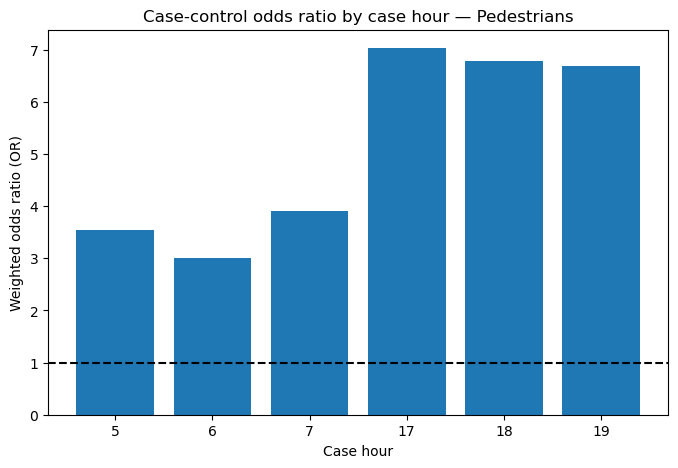

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    ped_or_df["case_hour"].astype(str).to_numpy(),
    ped_or_df["weighted_OR"].to_numpy()
)

plt.axhline(1, color="black", linestyle="--")

plt.xlabel("Case hour")
plt.ylabel("Weighted odds ratio (OR)")
plt.title("Case-control odds ratio by case hour — Pedestrians")

plt.show()

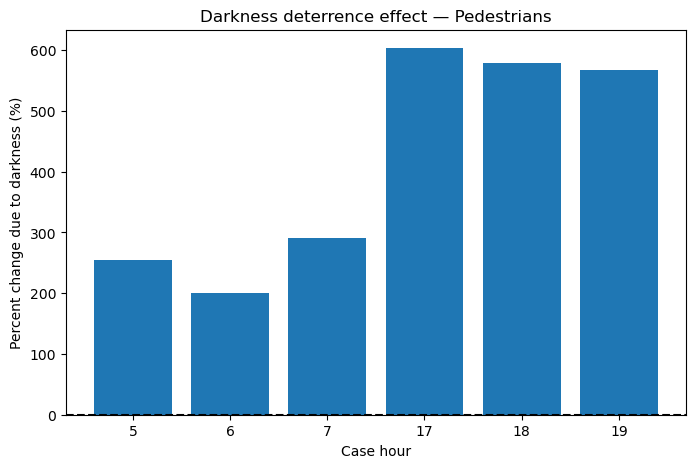

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    ped_or_df["case_hour"].astype(str).to_numpy(),
    ped_or_df["percent_effect"].to_numpy()
)

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Case hour")
plt.ylabel("Percent change due to darkness (%)")
plt.title("Darkness deterrence effect — Pedestrians")

plt.show()

In [13]:
cyc_sensor_results = []

for h in case_hours:
    res = compute_sensor_level_or(
        data=df,
        outcome="cyc",
        case_hour=h,
        day_control_hour=day_control_hour,
        dark_control_hour=dark_control_hour
    )
    cyc_sensor_results.append(res)

cyc_sensor_df = pd.concat(cyc_sensor_results, ignore_index=True)

cyc_or_df = (
    cyc_sensor_df.groupby("case_hour")
    .apply(lambda g: pd.Series({
        "n_sensors_used": g["sensor_id"].nunique(),
        "weighted_OR": np.average(g["OR"], weights=g["weight"]),
        "mean_OR": g["OR"].mean()
    }))
    .reset_index()
)

cyc_or_df["percent_effect"] = (cyc_or_df["weighted_OR"] - 1) * 100

cyc_or_df

/var/folders/8h/f8h6db8n04z7dkdqqxfyt7jm0000gn/T/ipykernel_18251/55894998.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cyc_sensor_df.groupby("case_hour")


,case_hour,n_sensors_used,weighted_OR,mean_OR,percent_effect
0,5,45.0,2.641718,2.695121,164.171787
1,6,46.0,1.491045,1.711702,49.104492
2,7,46.0,1.743056,1.833285,74.305612
3,17,46.0,3.801950,3.975500,280.194959
4,18,46.0,4.203243,4.589352,320.324274
5,19,46.0,4.100399,4.589476,310.039929
6,20,39.0,3.847880,4.381875,284.787999


In [14]:
cyc_or_df = cyc_or_df[cyc_or_df["n_sensors_used"] >= 45]

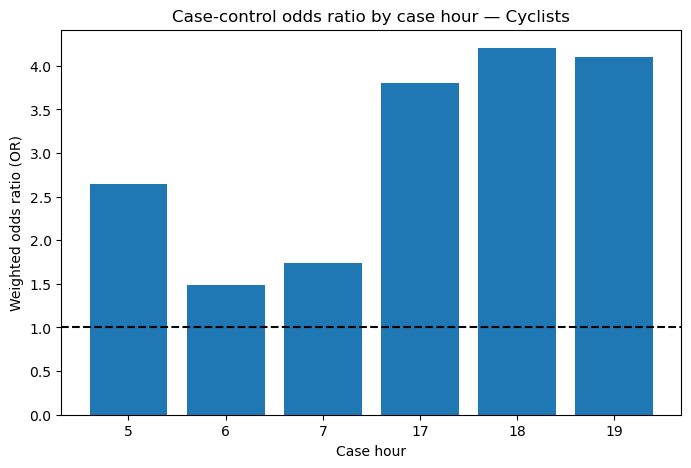

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    cyc_or_df["case_hour"].astype(str).to_numpy(),
    cyc_or_df["weighted_OR"].to_numpy()
)

plt.axhline(1, color="black", linestyle="--")

plt.xlabel("Case hour")
plt.ylabel("Weighted odds ratio (OR)")
plt.title("Case-control odds ratio by case hour — Cyclists")

plt.show()

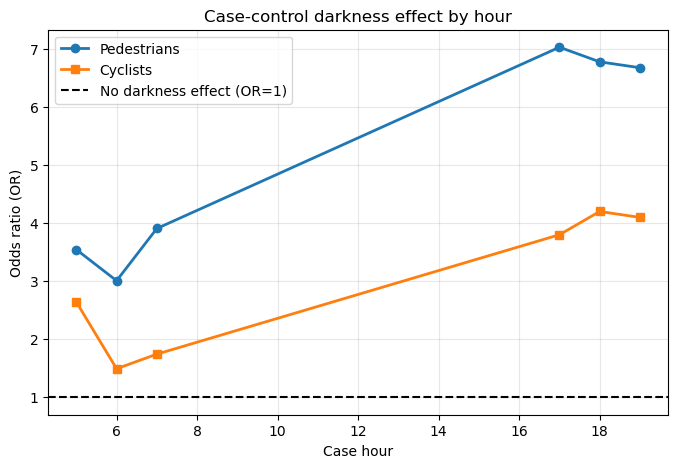

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    ped_or_df["case_hour"].to_numpy(),
    ped_or_df["weighted_OR"].to_numpy(),
    marker="o",
    linewidth=2,
    label="Pedestrians"
)

plt.plot(
    cyc_or_df["case_hour"].to_numpy(),
    cyc_or_df["weighted_OR"].to_numpy(),
    marker="s",
    linewidth=2,
    label="Cyclists"
)

plt.axhline(1, linestyle="--", color="black", label="No darkness effect (OR=1)")

plt.xlabel("Case hour")
plt.ylabel("Odds ratio (OR)")
plt.title("Case-control darkness effect by hour")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
results_table = ped_or_df[["case_hour","weighted_OR"]].copy()
results_table.rename(columns={
    "weighted_OR":"pedestrian_OR",
    
}, inplace=True)

results_table["cyclist_OR"] = cyc_or_df["weighted_OR"].values
#results_table["cyclist_percent_effect"] = cyc_or_df["percent_effect"].values

results_table

,case_hour,pedestrian_OR,cyclist_OR
0,5,3.545575,2.641718
1,6,3.008964,1.491045
2,7,3.909518,1.743056
3,17,7.035266,3.801950
4,18,6.783348,4.203243
5,19,6.681551,4.100399


### Case-control analysis results

Odds ratios greater than 1 indicate that pedestrian or cyclist flows are lower in darkness compared with daylight.

Across all analysed case hours, the odds ratios exceed 1 for both pedestrians and cyclists, suggesting that darkness is associated with reduced active travel.

Pedestrian OR values are consistently higher than cyclist OR values, indicating that walking behaviour may be more sensitive to ambient light conditions.

The effect is strongest during evening case hours (17–19), where OR values exceed 6 for pedestrians. This suggests that darkness has a particularly strong deterrent effect on evening walking activity.

The case-control analysis and time-series model both indicate that darkness is associated with reduced pedestrian and cyclist flows. While the case-control method compares matched daylight and darkness periods, the time-series model controls for additional temporal patterns such as autocorrelation and daily cycles. Both approaches consistently suggest that walking behaviour is more sensitive to darkness than cycling behaviour.